In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

sns.set_theme(style='darkgrid')
%matplotlib inline

## Load FD001 and FD002

In [2]:
COLS = (
    ['engine_id', 'cycle'] +
    [f'op_{i}' for i in range(1,4)] +
    [f's{i}' for i in range(1,22)]
)

train1 = pd.read_csv('../CMAPSSData/train_FD001.txt', sep=r'\s+', header=None, names=COLS)
train2 = pd.read_csv('../CMAPSSData/train_FD002.txt', sep=r'\s+', header=None, names=COLS)

print("FD001 engines:", train1['engine_id'].nunique(), "| rows:", len(train1))
print("FD002 engines:", train2['engine_id'].nunique(), "| rows:", len(train2))



FD001 engines: 100 | rows: 20631
FD002 engines: 260 | rows: 53759


## Visualize the operating condition

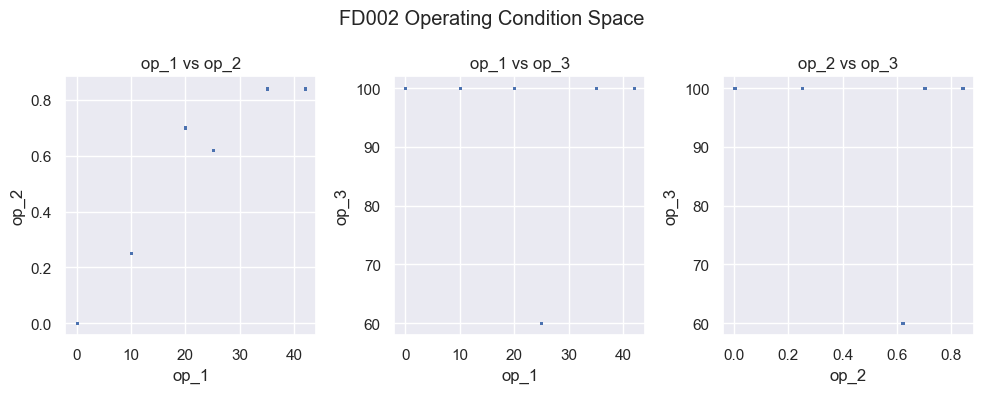

In [3]:
fig, axes = plt.subplots(1,3, figsize=(10,4))

op_pairs = [('op_1', 'op_2') , ('op_1', 'op_3'), ('op_2', 'op_3')]
for ax, (x, y) in zip(axes, op_pairs):
    ax.scatter(train2[x], train2[y], alpha=0.05, s=1)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}')


plt.suptitle('FD002 Operating Condition Space')
plt.tight_layout()
plt.show()

## K-means Clustering

In [4]:
op_cols = ['op_1', 'op_2', 'op_3']
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
train2['condition'] = kmeans.fit_predict(train2[op_cols])

print("Cluster sizes:")
print(train2['condition'].value_counts().sort_index())
print("\nCluster centers:")
centers = pd.DataFrame(kmeans.cluster_centers_, columns=op_cols)
print(centers.round(3))

Cluster sizes:
condition
0    13458
1     8122
2     8002
3     8044
4     8096
5     8037
Name: count, dtype: int64

Cluster centers:
     op_1   op_2   op_3
0  42.003  0.840  100.0
1  20.003  0.701  100.0
2  25.003  0.621   60.0
3   0.002  0.000  100.0
4  10.003  0.250  100.0
5  35.003  0.841  100.0


## Visualize Cluster

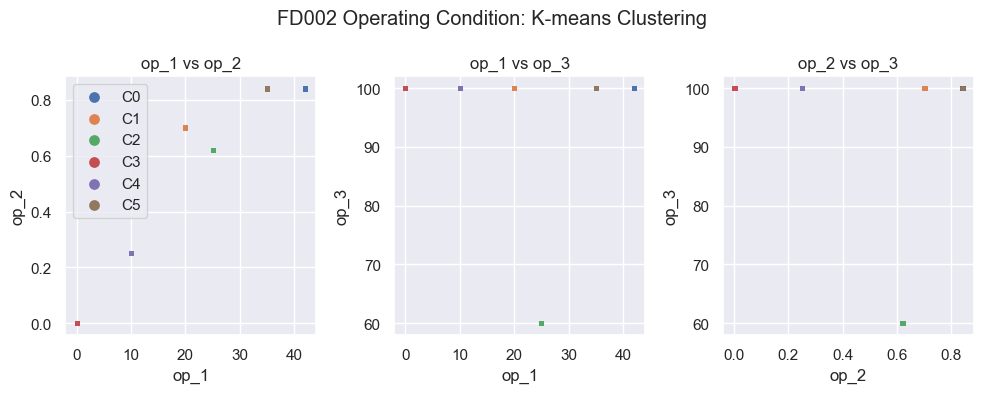

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(10,4))

op_pairs = [('op_1' , 'op_2'), ('op_1' , 'op_3'), ('op_2' , 'op_3')]
for ax, (x, y) in zip(axes, op_pairs):
    for c in range(6):
        subset = train2[train2['condition'] == c ]
        ax.scatter(subset[x], subset[y], alpha=0.3, s=5, label=f'C{c}')
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}')

legend = axes[0].legend(markerscale=3)
for lh in legend.legend_handles:
    lh.set_alpha(1)
plt.suptitle('FD002 Operating Condition: K-means Clustering')
plt.tight_layout()
plt.show()

## Per-condition sensor distribution

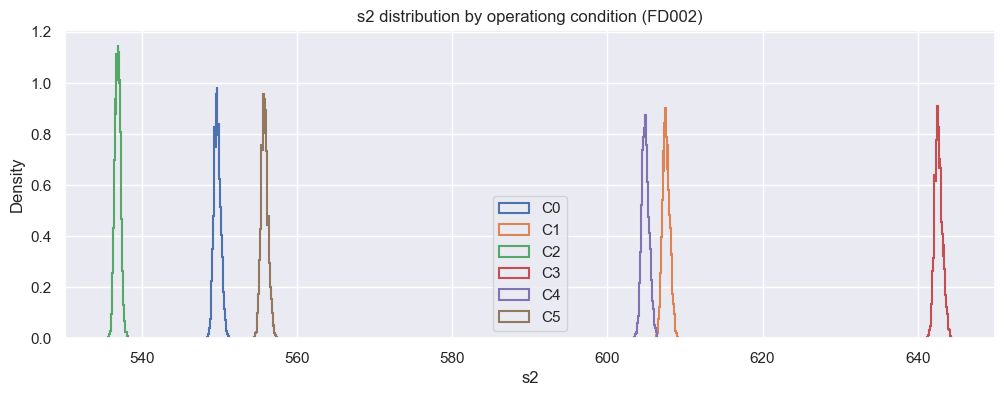

In [6]:
sensor = 's2'

fig, ax = plt.subplots(figsize=(12,4))
for c in range(6):
    subset = train2[train2['condition'] == c]
    ax.hist(subset[sensor], bins=40, density=True, label=f'C{c}',
        histtype='step', linewidth=1.5)

ax.set_title(f'{sensor} distribution by operationg condition (FD002)')
ax.set_xlabel(sensor)
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout
plt.show()

## FD001 vs FD002 Sensor distribution


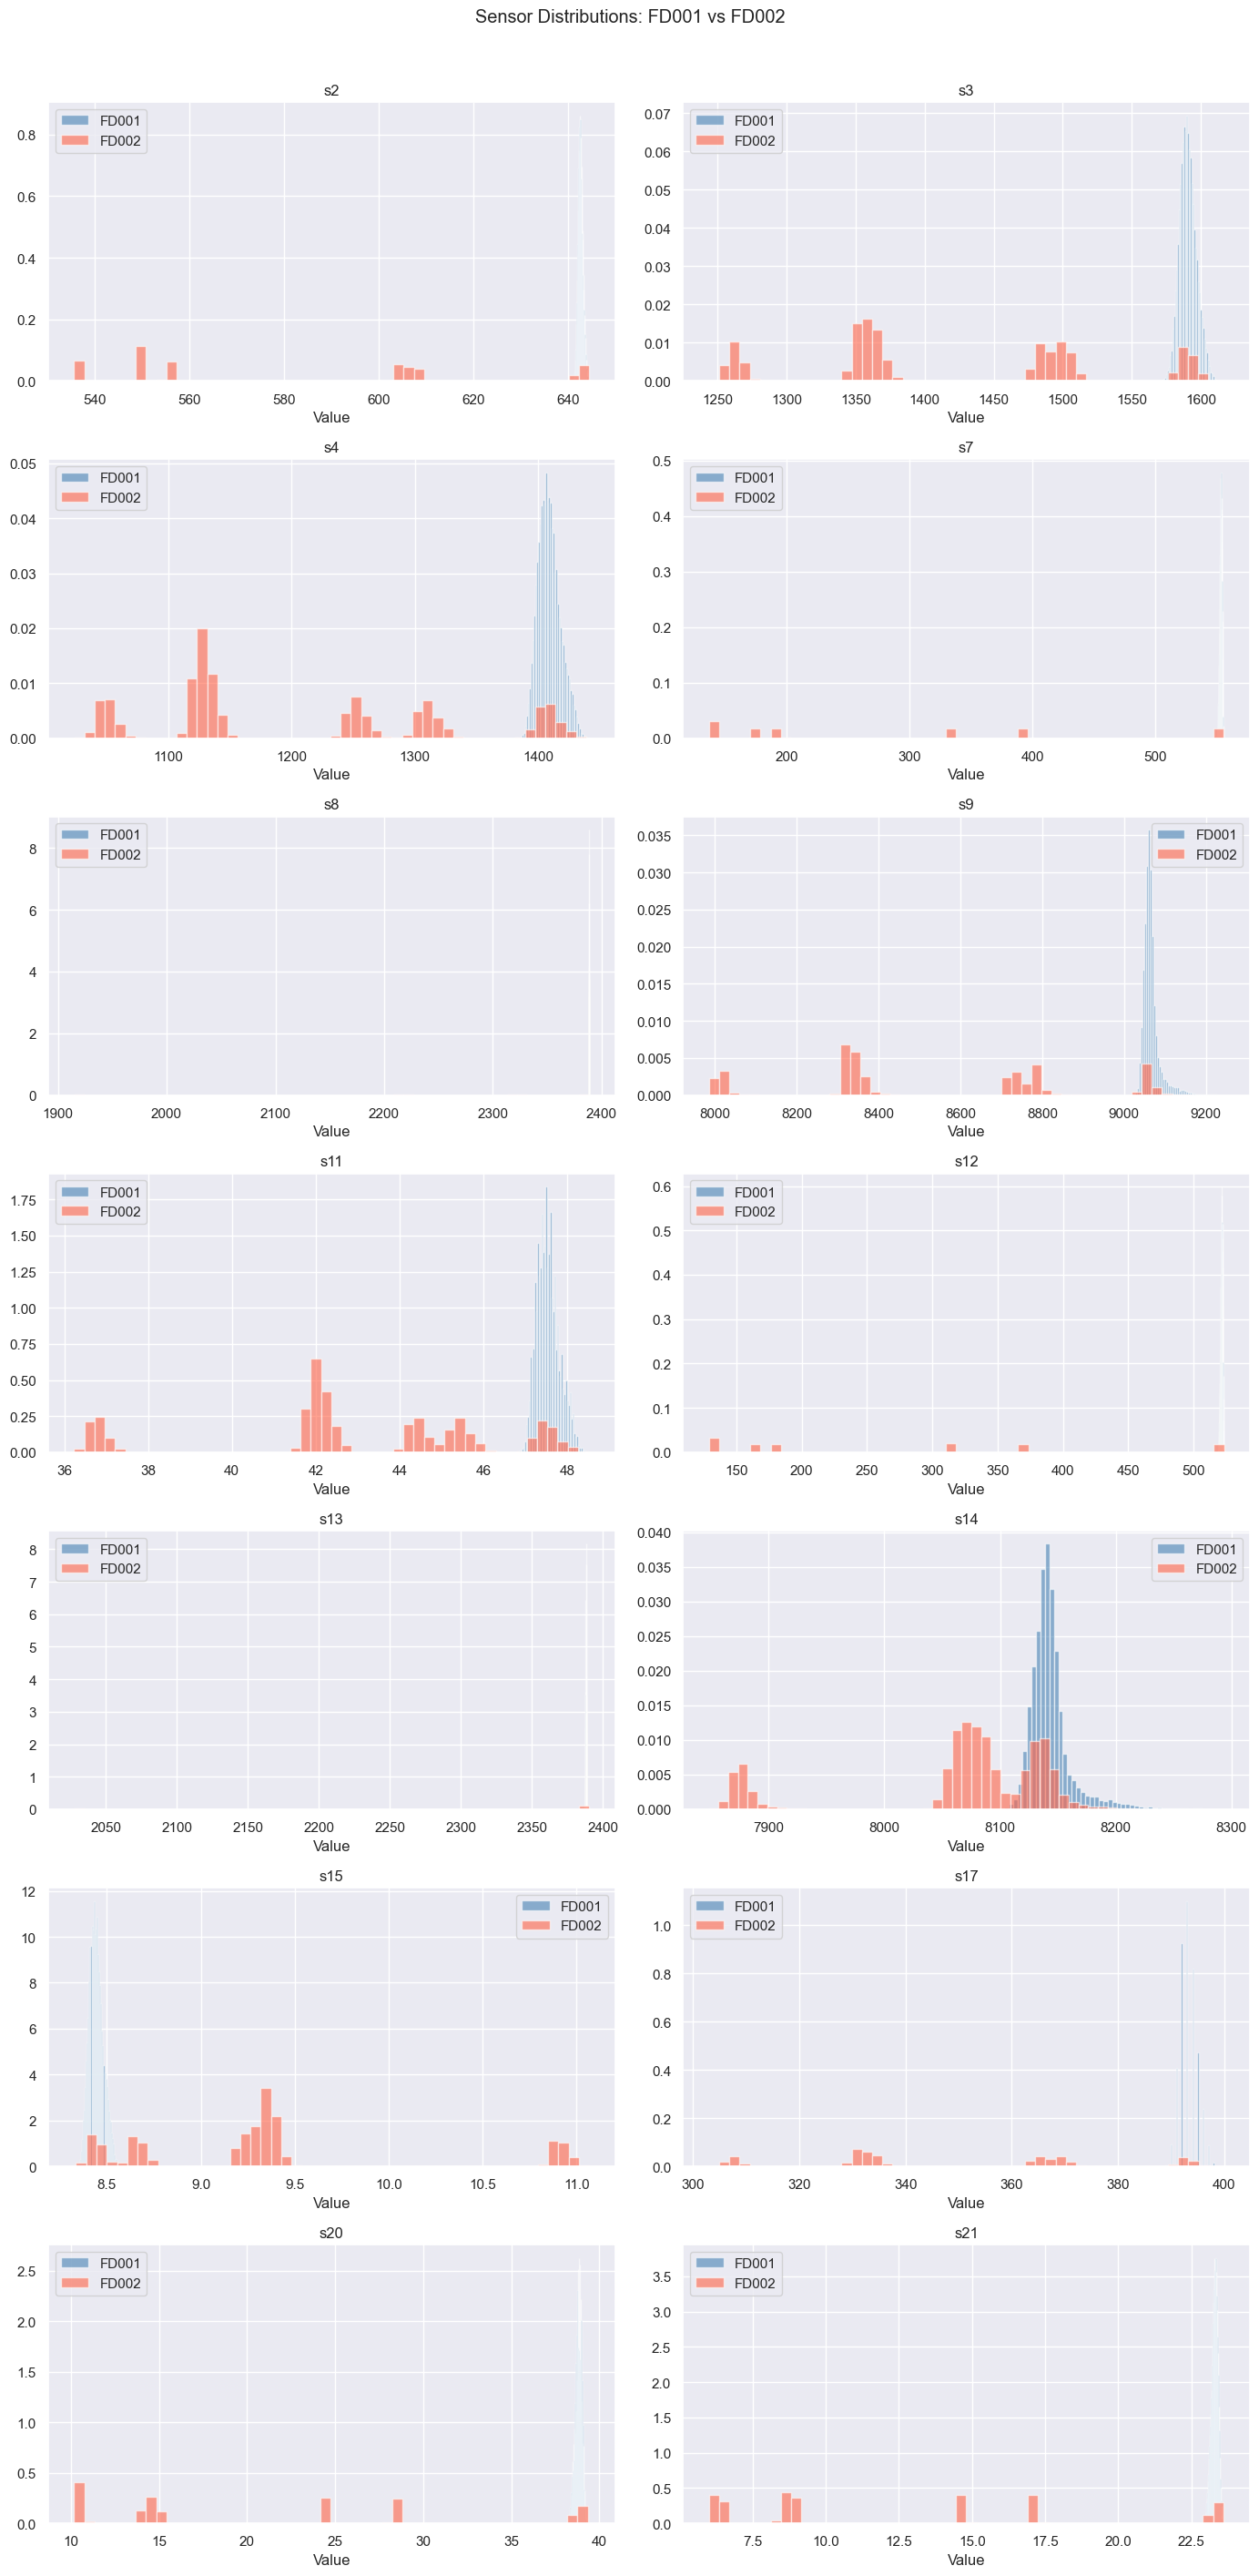

In [7]:
sensors_to_plot = ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']

fig, axes = plt.subplots(7, 2, figsize=(14, 28))
axes = axes.flatten()

for i, sensor in enumerate(sensors_to_plot):
    axes[i].hist(train1[sensor], bins=50, alpha=0.6, density=True, label='FD001', color='steelblue')
    axes[i].hist(train2[sensor], bins=50, alpha=0.6, density=True, label='FD002', color='tomato')
    axes[i].set_title(sensor)
    axes[i].set_xlabel('Value')
    axes[i].legend()

plt.suptitle('Sensor Distributions: FD001 vs FD002', y=1.01)
plt.tight_layout()
plt.show()

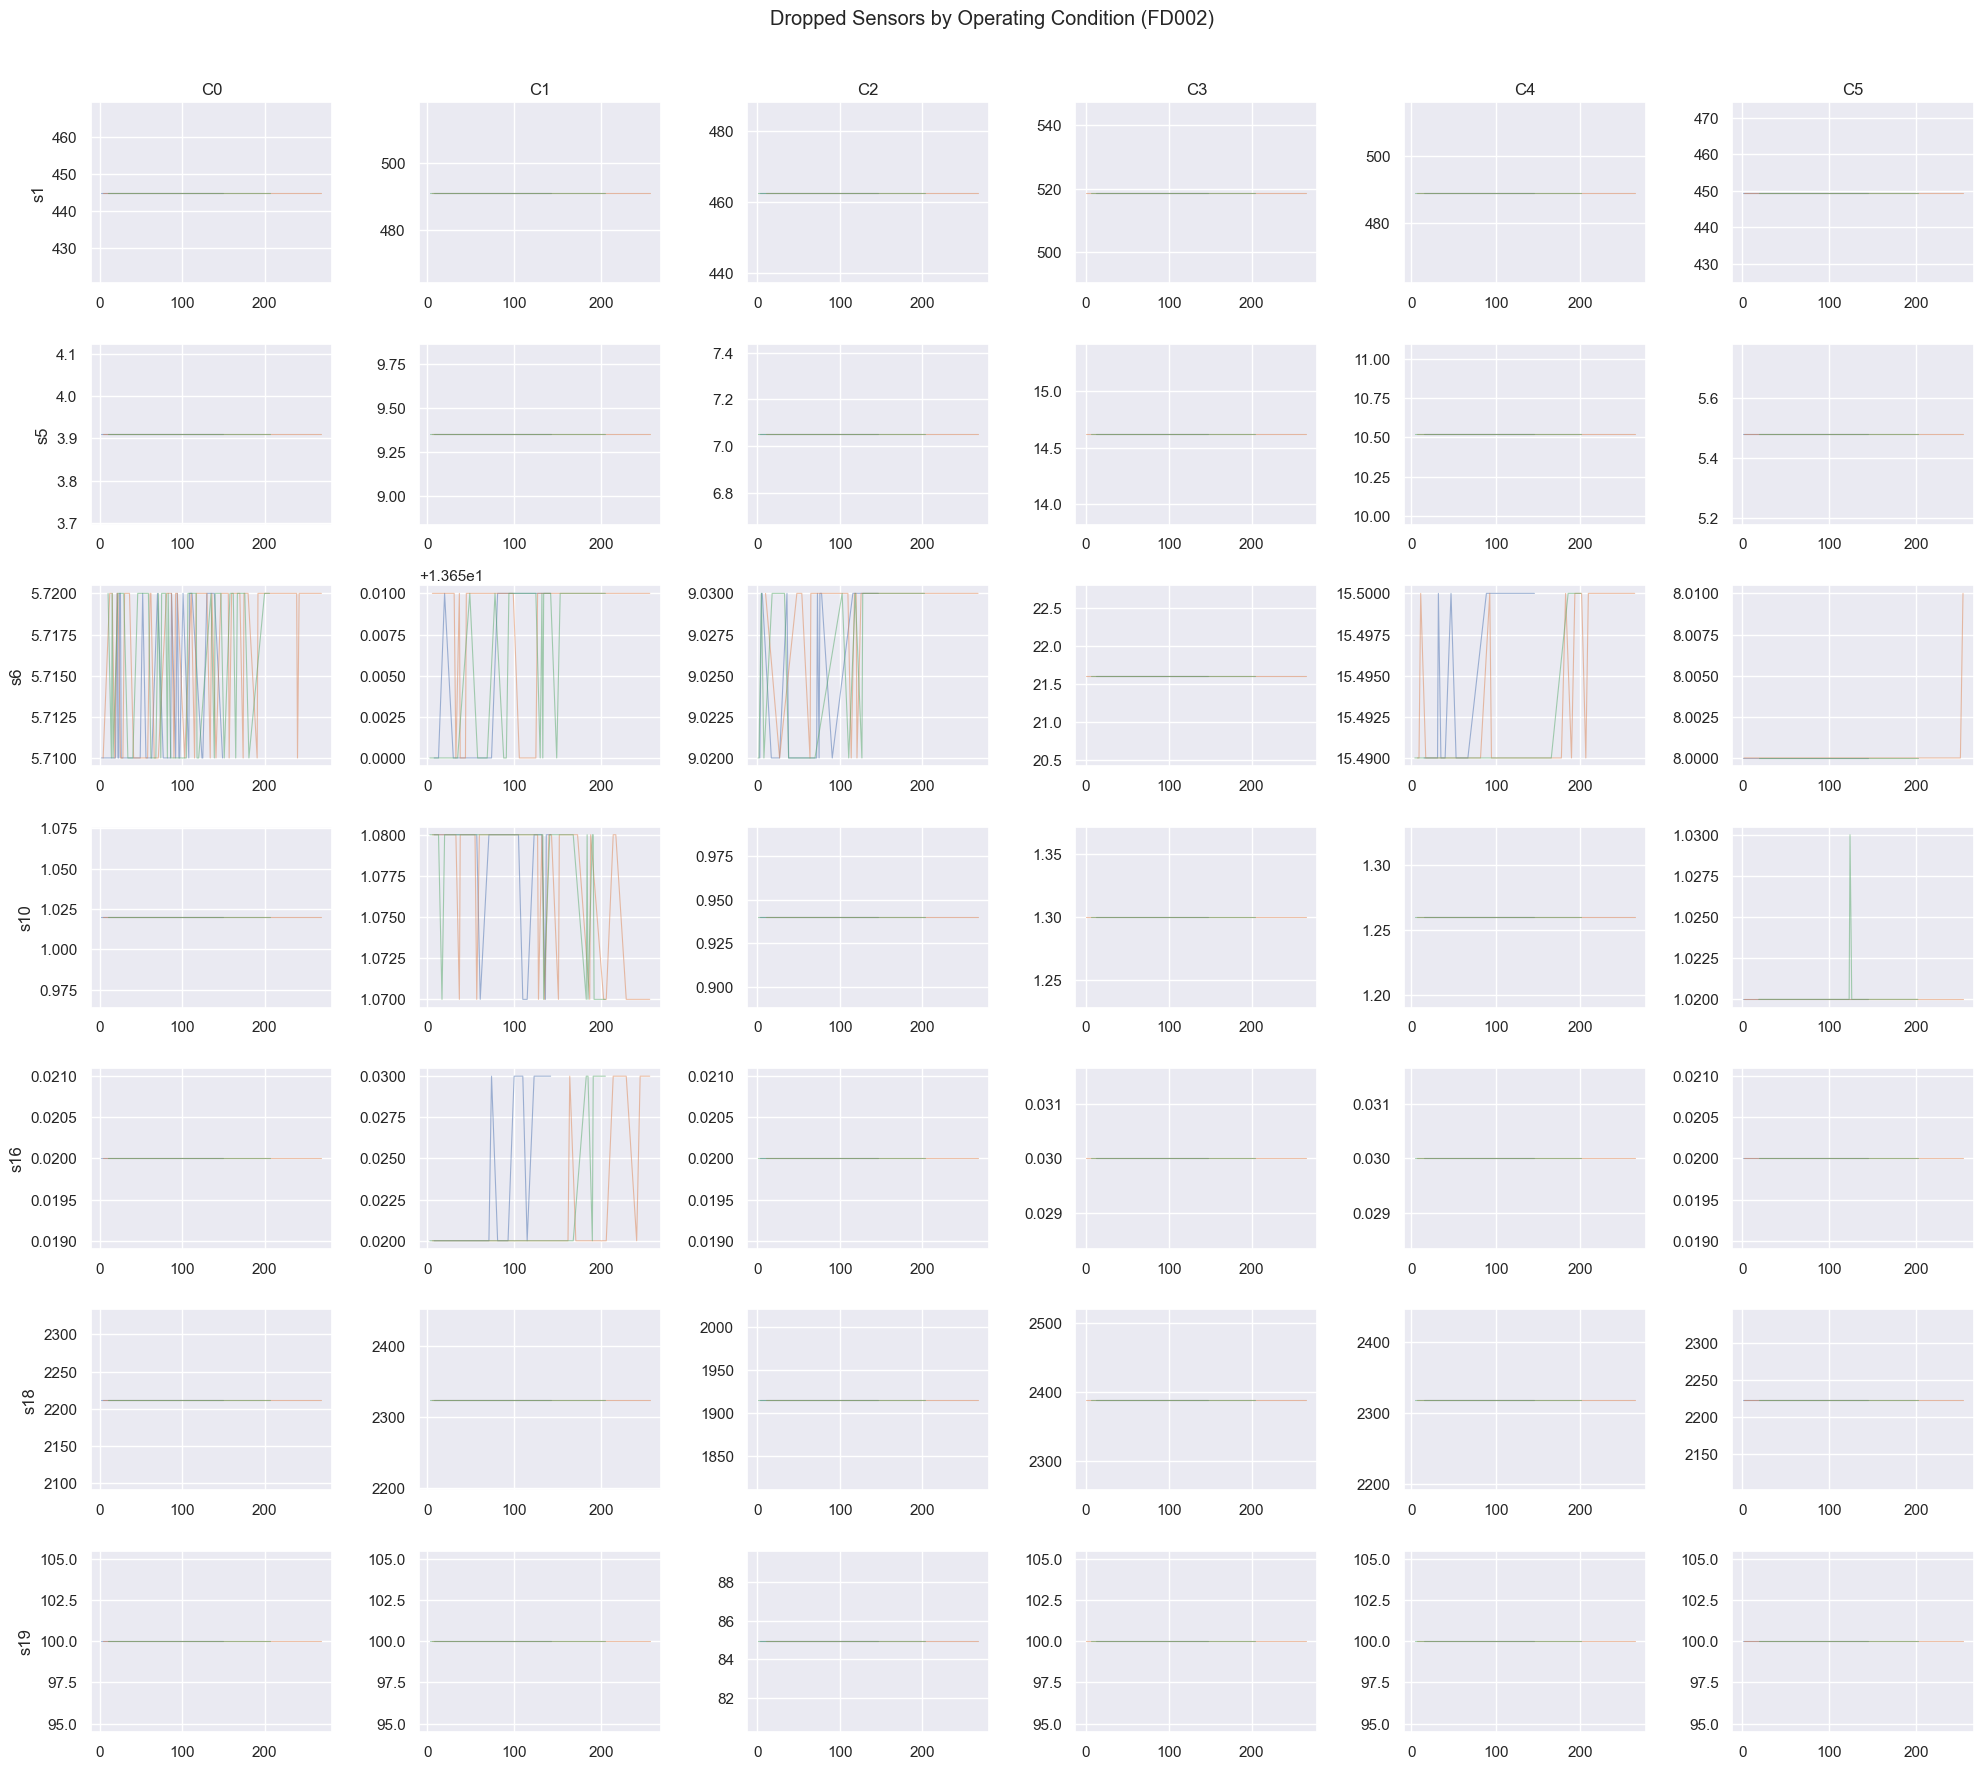

In [16]:
dropped = ['s1', 's5', 's6', 's10', 's16', 's18', 's19']

fig, axes = plt.subplots(len(dropped), 6, figsize=(20, len(dropped) * 2.5))

for i, sensor in enumerate(dropped):
    for c in range(6):
        subset = train2[train2['condition'] == c]
        for eng_id in subset['engine_id'].unique()[:3]:
            eng = subset[subset['engine_id'] == eng_id].sort_values('cycle')
            axes[i, c].plot(eng['cycle'], eng[sensor], alpha=0.5, linewidth=0.8)
        axes[i, c].set_title(f'C{c}' if i == 0 else '')
        axes[i, c].set_ylabel(sensor if c == 0 else '')

plt.suptitle('Dropped Sensors by Operating Condition (FD002)', y=1.01)
plt.tight_layout()
plt.show()

In [19]:
max_cycles = train2.groupby('engine_id')['cycle'].max().reset_index()
max_cycles.columns = ['engine_id', 'max_cycle']
train2 = train2.merge(max_cycles, on='engine_id')
train2['RUL'] = (train2['max_cycle'] - train2['cycle']).clip(upper=125)
train2.drop(columns='max_cycle', inplace=True)

In [20]:
dropped = ['s1', 's5', 's6', 's10', 's16', 's18', 's19']

results = []
for sensor in dropped:
    for c in range(6):
        subset = train2[train2['condition'] == c]
        corr = subset[sensor].corr(subset['RUL'])
        results.append({'sensor': sensor, 'condition': c, 'corr': round(corr, 3)})

corr_df = pd.DataFrame(results).pivot(index='sensor', columns='condition', values='corr')
print(corr_df)

condition      0      1      2      3      4      5
sensor                                             
s1           NaN -0.000    NaN    NaN -0.000 -0.000
s10       -0.241  0.434  0.071 -0.000  0.038  0.094
s16       -0.000 -0.674    NaN -0.000 -0.000 -0.000
s18          NaN    NaN    NaN    NaN    NaN    NaN
s19          NaN    NaN -0.000    NaN    NaN    NaN
s5         0.000 -0.000  0.000 -0.000    NaN  0.000
s6        -0.299 -0.492 -0.320 -0.105 -0.691 -0.307


c:\miniconda3\envs\ml_crashcourse\Lib\site-packages\numpy\lib\_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\miniconda3\envs\ml_crashcourse\Lib\site-packages\numpy\lib\_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


## Sensor drop decision

The correlation table above shows per-condition RUL correlations for sensors initially considered for dropping.

**s6 is retained for FD002.** Unlike the other candidates, s6 shows consistent negative correlation with RUL across all 6 operating conditions (ranging from -0.10 to -0.69). This means as the engine degrades, s6 reliably decreases regardless of which operating regime the engine is in — making it a genuinely useful feature.

The remaining sensors (s1, s5, s10, s16, s18, s19) are dropped. They are either flat (NaN correlation, zero variance) or show inconsistent/near-zero correlations across conditions, contributing noise rather than signal.

**Note:** In FD001 (single operating condition), s6 appeared flat and was dropped. The multi-condition structure of FD002 reveals its true degradation signal — it was previously confounded by condition-mixing.